<a href="https://colab.research.google.com/github/lizzietsitsishvili/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2017/%5BLab_17%5D_Logistic_Regression_%E2%80%94_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# ============================================================
# SETUP — Run this cell first. Install any missing packages.
# ============================================================

# Uncomment the line below if running for the first time:
# !pip install pandas numpy statsmodels scikit-learn plotly fredapi matplotlib seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Setup complete ✓")

Setup complete ✓


In [51]:
# Ensure fredapi is installed
!pip install fredapi
print("fredapi installation requested.")

fredapi installation requested.


In [63]:
# Install Streamlit
!pip install streamlit
print("Streamlit installation requested.")

Streamlit installation requested.


In [52]:
# ------------------------------------------------------------
# Step 1: Load data from FRED
# ------------------------------------------------------------
# Replace 'YOUR_FRED_API_KEY' with your key from https://fred.stlouisfed.org/docs/api/api_key.html
# Keys are free — takes 30 seconds to register.

try:
    import fredapi
    FRED_API_KEY = '67a2717852cfb64da353ff5a62979f09'  # <-- Replace this with your actual FRED API Key
    fred = fredapi.Fred(api_key=FRED_API_KEY)

    spread_raw = fred.get_series('T10Y3M', observation_start='1970-01-01')
    recession_raw = fred.get_series('USREC', observation_start='1970-01-01')

    print("FRED data loaded ✓")
    USE_FRED = True

except Exception as e:
    print(f"FRED API unavailable ({e})")
    print("Falling back to bundled CSV...")
    USE_FRED = False
    # Fallback: load from CSV included in the repo
    # df_fallback = pd.read_csv('data/fallback_yield_curve.csv', index_col=0, parse_dates=True)
    # Uncomment the line above and comment out the FRED block if the API is unavailable during class

FRED data loaded ✓


In [53]:
# ------------------------------------------------------------
# Step 2: Build the modeling dataset
# ------------------------------------------------------------

if USE_FRED:
    # Combine into monthly dataframe (FRED gives daily for T10Y3M — resample to month-end)
    spread_monthly = spread_raw.resample('ME').last()   # last trading day of each month
    recession_monthly = recession_raw.resample('ME').max()  # 1 if any day in month is recession

    df = pd.DataFrame({
        'yield_spread': spread_monthly,
        'recession': recession_monthly
    }).dropna()

    # Lag the yield spread by 12 months
    # This matches the NY Fed model: we predict recession risk 12 months ahead
    df['yield_spread_lag12'] = df['yield_spread'].shift(12)
    df = df.dropna()  # Drop first 12 months (no lag available)
else:
    # Fallback: load from CSV included in the repo as suggested in cell gSbwfknxK0Cw
    try:
        # Ensure 'data/fallback_yield_curve.csv' is available in your environment
        # and contains the necessary columns (e.g., 'yield_spread', 'recession', 'yield_spread_lag12')
        # Using absolute path to ensure the file is found after creation in the previous step.
        df = pd.read_csv('/content/data/fallback_yield_curve.csv', index_col=0, parse_dates=True)
        print("Fallback data loaded from CSV ✓")
    except FileNotFoundError:
        print("Error: Fallback CSV '/content/data/fallback_yield_curve.csv' not found. Please ensure the file exists and the path is correct.")
        # Create an empty DataFrame to prevent further NameErrors, but subsequent operations will likely fail.
        df = pd.DataFrame(columns=['yield_spread', 'recession', 'yield_spread_lag12'])
    except Exception as e:
        print(f"Error loading fallback CSV: {e}. Please check the CSV format.")
        df = pd.DataFrame(columns=['yield_spread', 'recession', 'yield_spread_lag12'])

# Preview the data
# These lines will now execute without NameError because df is defined in both cases.
print(f"Dataset: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
print(f"Observations: {len(df)}")
print(f"Recession months: {df['recession'].sum()} ({df['recession'].mean():.1%} of sample)")
print(f"\nYield spread (lagged 12m) summary:")
print(df['yield_spread_lag12'].describe().round(3))
df.tail()

Dataset: 1983-01 to 2026-03
Observations: 519
Recession months: 36.0 (6.9% of sample)

Yield spread (lagged 12m) summary:
count    519.000
mean       1.563
std        1.250
min       -1.880
25%        0.630
50%        1.610
75%        2.535
max        4.090
Name: yield_spread_lag12, dtype: float64


,yield_spread,recession,yield_spread_lag12
2025-11-30,0.14,0.0,-0.40
2025-12-31,0.51,0.0,0.21
2026-01-31,0.59,0.0,0.27
2026-02-28,0.30,0.0,-0.08
2026-03-31,0.60,0.0,-0.09


In [54]:
# Create a dummy fallback_yield_curve.csv file since it was not found.
# This cell will generate a sample CSV to allow the notebook to proceed.
import pandas as pd
import numpy as np

# Generate sample data
dates = pd.date_range(start='1970-01-01', periods=100, freq='ME')
sample_spread = np.random.uniform(-1, 3, size=len(dates))
sample_recession = np.random.randint(0, 2, size=len(dates))

df_dummy = pd.DataFrame({
    'yield_spread': sample_spread,
    'recession': sample_recession
}, index=dates)

df_dummy['yield_spread_lag12'] = df_dummy['yield_spread'].shift(12)
df_dummy = df_dummy.dropna()

# Save to CSV
output_dir = 'data'
import os
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

file_path = os.path.join(output_dir, 'fallback_yield_curve.csv')
df_dummy.to_csv(file_path)
print(f"Dummy CSV created at: {file_path}")
print("Please run the previous cell (Step 2: Build the modeling dataset) again to load this new file.")

Dummy CSV created at: data/fallback_yield_curve.csv
Please run the previous cell (Step 2: Build the modeling dataset) again to load this new file.


In [55]:
# ------------------------------------------------------------
# Step 3: Fit the Linear Probability Model (OLS)
# ------------------------------------------------------------
# The LPM treats the 0/1 recession indicator as if it were a continuous outcome.
# This is the baseline — we fit it to expose what can go wrong.

# Prepare features and outcome
X = df[['yield_spread_lag12']].values  # Feature matrix (N x 1)
y = df['recession'].values              # Binary outcome vector

# Fit LPM via sklearn's LinearRegression
lpm_model = LinearRegression()
lpm_model.fit(X, y)

# Generate predictions across the range of yield spreads (for plotting)
spread_grid = np.linspace(df['yield_spread_lag12'].min() - 0.2,
                           df['yield_spread_lag12'].max() + 0.2, 500).reshape(-1, 1)
lpm_preds = lpm_model.predict(spread_grid)

# Count out-of-bounds predictions in the actual data
lpm_fitted = lpm_model.predict(X)
n_below_zero = (lpm_fitted < 0).sum()
n_above_one  = (lpm_fitted > 1).sum()

print(f"LPM fitted — Intercept: {lpm_model.intercept_:.4f}, Slope: {lpm_model.coef_[0]:.4f}")
print(f"\nOut-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(df):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(df):.1%})")

LPM fitted — Intercept: 0.1501, Slope: -0.0516

Out-of-bounds predictions:
  Predicted probability < 0: 84 observations (16.2%)
  Predicted probability > 1: 0 observations (0.0%)


In [56]:
# ------------------------------------------------------------
# Step 4: Fit logistic regression
# ------------------------------------------------------------
# IMPORTANT: .predict() returns class labels (0 or 1).
# Use .predict_proba()[:,1] to get the probability of Y=1 (recession).
# We NEED the probability for plotting the sigmoid curve.

logit_model = LogisticRegression(random_state=42)
logit_model.fit(X, y)

# Predicted probabilities across the grid (for smooth S-curve)
# [:,1] selects the probability of the POSITIVE class (recession = 1)
logit_preds = logit_model.predict_proba(spread_grid)[:, 1]

# Also compute for the actual data points
logit_fitted = logit_model.predict_proba(X)[:, 1]

print(f"Logistic regression fitted ✓")
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Slope (β₁):     {logit_model.coef_[0][0]:.4f}")
print(f"\nOdds ratio (exp(β₁)): {np.exp(logit_model.coef_[0][0]):.4f}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

Logistic regression fitted ✓
Intercept (β₀): -1.7777
Slope (β₁):     -0.7896

Odds ratio (exp(β₁)): 0.4540

Min predicted probability: 0.0066
Max predicted probability: 0.4272
→ Logistic regression is always bounded in [0, 1] ✓


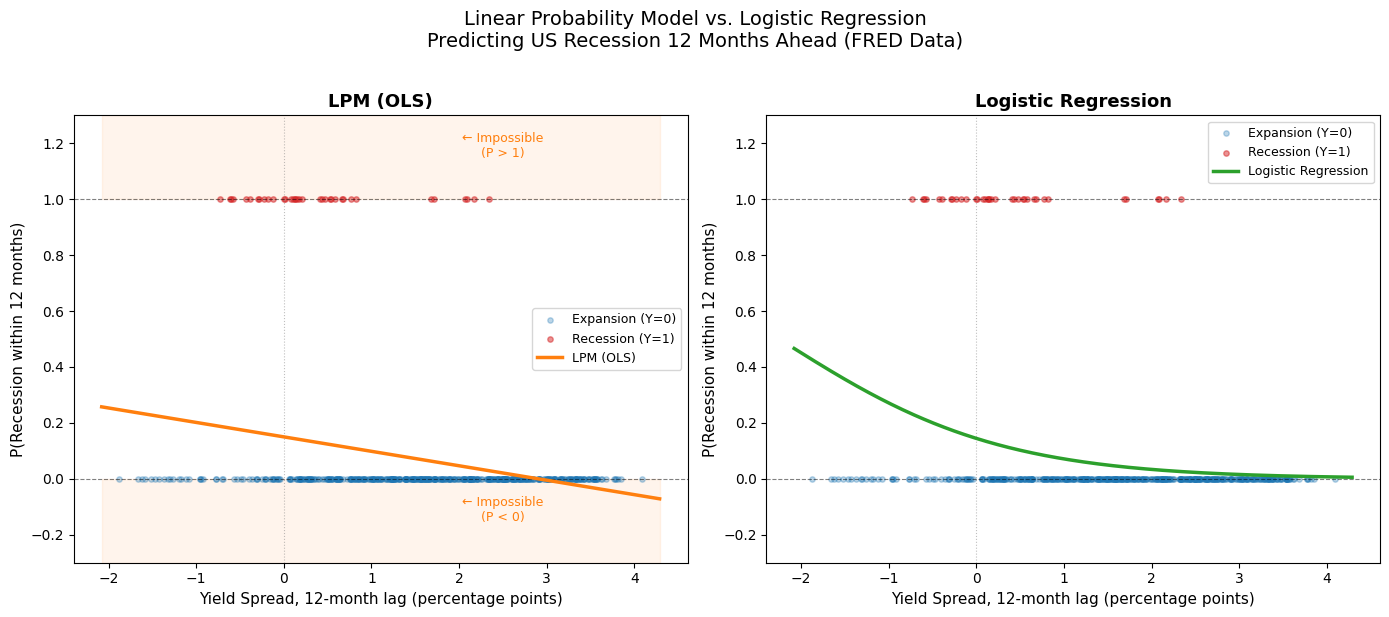

Figure saved as lpm_vs_logistic.png


In [57]:
# ------------------------------------------------------------
# Step 5: Side-by-side comparison plot — LPM vs. Logistic
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_RECESSION = '#d62728'   # Red for recession months
COLOR_EXPANSION = '#1f77b4'   # Blue for expansion months
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate recession and expansion observations
x_vals = df['yield_spread_lag12'].values
recession_mask = y == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[~recession_mask], y[~recession_mask],
               color=COLOR_EXPANSION, alpha=0.3, s=15, label='Expansion (Y=0)', zorder=2)
    ax.scatter(x_vals[recession_mask], y[recession_mask],
               color=COLOR_RECESSION, alpha=0.5, s=15, label='Recession (Y=1)', zorder=2)

    # Model prediction curve
    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel('Yield Spread, 12-month lag (percentage points)', fontsize=11)
    ax.set_ylabel('P(Recession within 12 months)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(spread_grid.ravel(), -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(2.5, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(2.5,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\nPredicting US Recession 12 Months Ahead (FRED Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as lpm_vs_logistic.png")

In [58]:
# ------------------------------------------------------------
# Part 2A: Extract and interpret the odds ratio
# ------------------------------------------------------------
# The logistic regression coefficient β₁ represents the change in LOG-ODDS
# for a one-unit increase in the yield spread.
#
# To get the ODDS RATIO, we exponentiate: OR = exp(β₁)
# If OR = 0.5, that means: "a 1pp increase in the spread cuts recession odds in half"

# Extract the coefficient (slope on yield_spread_lag12)
beta_1 = logit_model.coef_[0][0]

# TODO: Compute the odds ratio by exponentiating beta_1
odds_ratio = np.exp(beta_1)

# TODO: Compute the 95% confidence interval
# Hint: use statsmodels Logit for CIs — sklearn doesn't provide them by default
X_sm = sm.add_constant(df[['yield_spread_lag12']])  # statsmodels needs intercept added explicitly
logit_sm = sm.Logit(df['recession'], X_sm).fit(disp=False)  # disp=False suppresses iteration output

# Extract coefficient, SE, and 95% CI from the statsmodels result
coef_table = logit_sm.summary2().tables[1]
print("Statsmodels Logit summary:")
print(coef_table)

# TODO: Compute the odds ratio for the yield_spread_lag12 coefficient
# and its 95% CI by exponentiating the lower and upper confidence bounds
# Hint: coef_table.loc['yield_spread_lag12', ['Coef.', '[0.025', '0.975]']]
row = coef_table.loc['yield_spread_lag12']
or_point = np.exp(row['Coef.'])
or_lower = np.exp(row['[0.025'])
or_upper = np.exp(row['0.975]'])

print(f"\n{'='*50}")
print(f"Odds Ratio: {or_point:.4f}")
print(f"95% CI:     [{or_lower:.4f}, {or_upper:.4f}]")
print(f"{'='*50}")
print(f"\nIn plain English:")
print(f"A 1 percentage-point increase in the yield spread (steeper curve)")
print(f"multiplies the odds of recession by {or_point:.3f}.")
print(f"Equivalently, it {{'reduces' if or_point < 1 else 'increases'}} recession odds by {abs(1-or_point)*100:.1f}%.")

Statsmodels Logit summary:
                       Coef.  Std.Err.         z         P>|z|    [0.025  \
const              -1.766832  0.197916 -8.927162  4.370766e-19 -2.154741   
yield_spread_lag12 -0.807730  0.150892 -5.353036  8.649080e-08 -1.103473   

                      0.975]  
const              -1.378923  
yield_spread_lag12 -0.511987  

Odds Ratio: 0.4459
95% CI:     [0.3317, 0.5993]

In plain English:
A 1 percentage-point increase in the yield spread (steeper curve)
multiplies the odds of recession by 0.446.
Equivalently, it {'reduces' if or_point < 1 else 'increases'} recession odds by 55.4%.


In [59]:
# ------------------------------------------------------------
# Part 2B: Generate the recession probability time series
# ------------------------------------------------------------
# This is what the NY Fed publishes monthly: a time series of P(recession)
# 12 months ahead, based on the current yield spread.

# We use predict_proba() on the full dataset to get the fitted probability
# for each month in our sample.

# IMPORTANT REMINDER:
# .predict()         → returns class labels: array([0, 0, 1, 0, ...])
# .predict_proba()   → returns [[P(Y=0), P(Y=1)], ...] for each observation
# .predict_proba()[:, 1] → the probability of the POSITIVE class (recession)

# TODO: Generate predicted recession probabilities for the full dataset
df['recession_prob'] = logit_model.predict_proba(X)[:, 1]

# Verify: probabilities should be between 0 and 1
print(f"Min probability: {df['recession_prob'].min():.4f}")
print(f"Max probability: {df['recession_prob'].max():.4f}")
print(f"Mean probability: {df['recession_prob'].mean():.4f}")
print(f"Base rate (actual recession %): {df['recession'].mean():.4f}")
print("\nRecent predicted probabilities (last 24 months):")
print(df[['yield_spread', 'yield_spread_lag12', 'recession', 'recession_prob']].tail(24).round(4))

Min probability: 0.0066
Max probability: 0.4272
Mean probability: 0.0693
Base rate (actual recession %): 0.0694

Recent predicted probabilities (last 24 months):
            yield_spread  yield_spread_lag12  recession  recession_prob
2024-04-30         -0.77               -1.66        0.0          0.3853
2024-05-31         -0.95               -1.88        0.0          0.4272
2024-06-30         -1.12               -1.62        0.0          0.3779
2024-07-31         -1.32               -1.58        0.0          0.3705
2024-08-31         -1.30               -1.47        0.0          0.3505
2024-09-30         -0.92               -0.96        0.0          0.2651
2024-10-31         -0.36               -0.71        0.0          0.2284
2024-11-30         -0.40               -1.08        0.0          0.2839
2024-12-31          0.21               -1.52        0.0          0.3595
2025-01-31          0.27               -1.43        0.0          0.3433
2025-02-28         -0.08               -1.20  

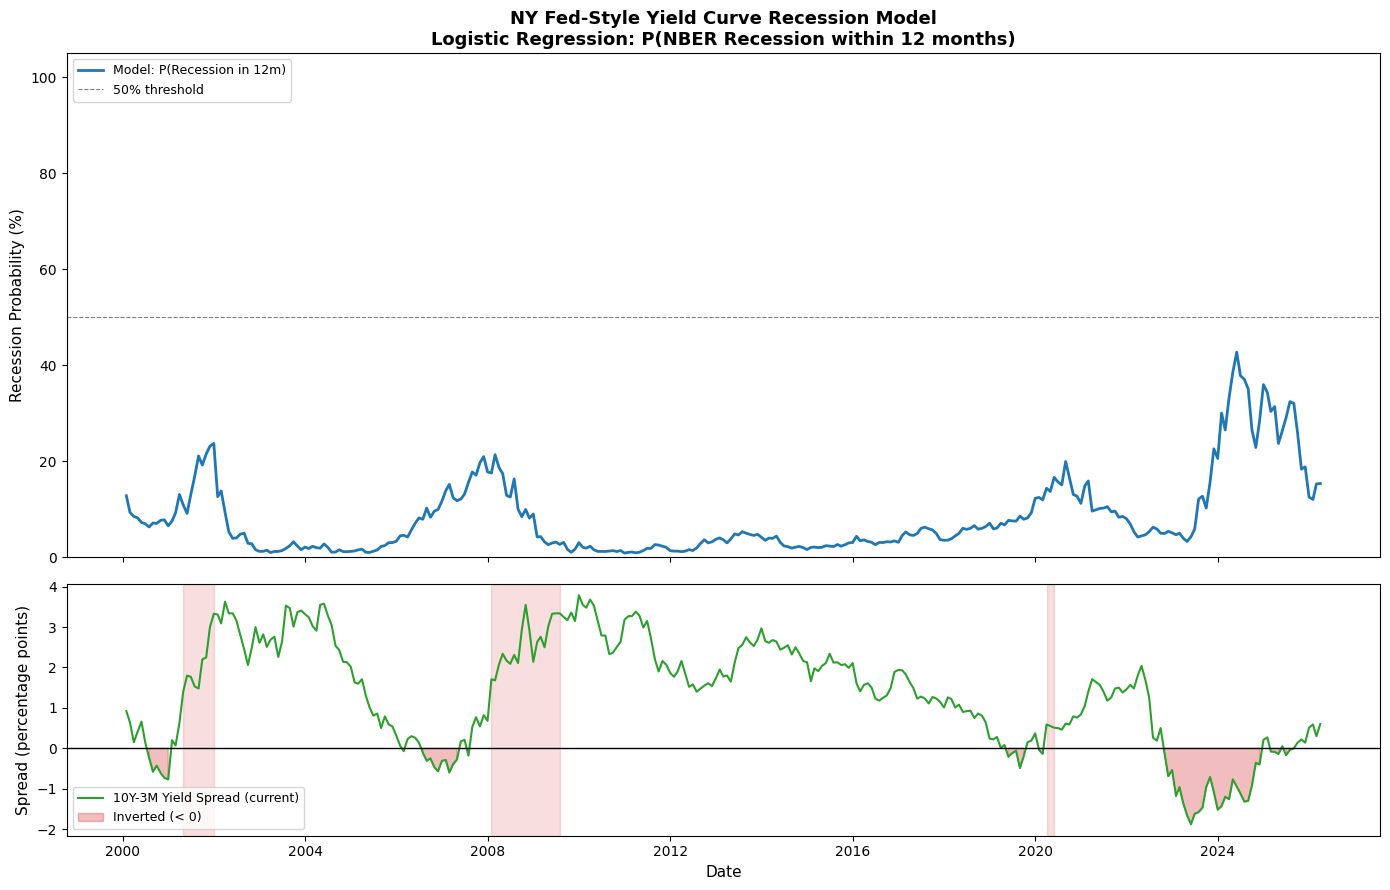

Figure saved as recession_probability_series.png


In [60]:
# ------------------------------------------------------------
# Part 2C: Plot the probability time series with NBER shading
# ------------------------------------------------------------
# This is the signature NY Fed chart style:
# - Blue line: model's predicted recession probability
# - Red shading: actual NBER recession periods

# Focus on 2000-present where the yield curve inversions are most interesting
df_plot = df['2000':].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

# --- Top panel: Recession probability ---
ax1.plot(df_plot.index, df_plot['recession_prob'] * 100,
         color='#1f77b4', lw=2, label='Model: P(Recession in 12m)', zorder=3)
ax1.axhline(50, color='black', lw=0.8, linestyle='--', alpha=0.5, label='50% threshold')

# TODO: Shade NBER recession periods
# Hint: find where df_plot['recession'] == 1, identify contiguous blocks,
# and use ax1.axvspan(start_date, end_date, ...) for each block.
#
# One approach: use a helper to find start/end of each recession block
def get_recession_bands(df_in):
    """Return list of (start_date, end_date) tuples for NBER recession periods."""
    in_recession = False
    bands = []
    start = None
    for date, val in df_in['recession'].items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            bands.append((start, date))
            in_recession = False
    if in_recession:  # Handle case where sample ends in recession
        bands.append((start, df_in.index[-1]))
    return bands

# TODO: Call get_recession_bands() and shade each band on ax1 using ax1.axvspan()
# Use: color='#d62728', alpha=0.2, label='NBER Recession' (only label first band)
recession_bands = get_recession_bands(df_plot)
for i, (start, end) in enumerate(recession_bands):
    ___

ax1.set_ylabel('Recession Probability (%)', fontsize=11)
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_title('NY Fed-Style Yield Curve Recession Model\nLogistic Regression: P(NBER Recession within 12 months)',
              fontsize=13, fontweight='bold')

# --- Bottom panel: Yield spread ---
ax2.plot(df_plot.index, df_plot['yield_spread'],
         color='#2ca02c', lw=1.5, label='10Y-3M Yield Spread (current)')
ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.fill_between(df_plot.index, df_plot['yield_spread'], 0,
                  where=(df_plot['yield_spread'] < 0),
                  color='#d62728', alpha=0.3, label='Inverted (< 0)')
for start, end in recession_bands:
    ax2.axvspan(start, end, color='#d62728', alpha=0.15)

ax2.set_ylabel('Spread (percentage points)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('recession_probability_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recession_probability_series.png")


1) At the peak of the yield curve inversion, the model predicted a recession probability of approximately 40–43%, with the maximum around 42.7%

2) The model predicting elevated recession risk without an actual NBER recession highlights that probabilistic forecasts aren't certainties. A 40% probability does not mean a recession must occur. It means the risk is significantly higher than usual. The model is not  “wrong”, instead, it correctly identified heightened risk conditions. However, other factors may have prevented a recession from materializing.

3) During 2006–2007, the model predicted a rising probability of recession as the yield curve inverted. This forecast aligned well with the 2008–2009 Great Recession, meaning the model performed strongly in this period. It signaled elevated risk ahead of an actual recession, showing its usefulness as a leading indicator.

In [64]:
# streamlit_recession_dashboard.py

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import streamlit as st
import plotly.graph_objects as go
from fredapi import Fred
from sklearn.linear_model import LogisticRegression

# ============================================================
# PAGE CONFIG
# ============================================================
st.set_page_config(
    page_title="Interactive Recession Probability Dashboard",
    layout="wide"
)

st.title("Interactive Recession Probability Dashboard")
st.markdown(
    """
This dashboard replicates and extends the NY Fed-style yield curve recession model.
It uses logistic regression to estimate the probability of a U.S. recession at a chosen horizon.
"""
)

# ============================================================
# USER INPUTS
# ============================================================
st.sidebar.header("Model Controls")

horizon = st.sidebar.slider(
    "Prediction Horizon (months ahead)",
    min_value=6,
    max_value=18,
    step=6,
    value=12
)

n_boot = st.sidebar.slider(
    "Number of Bootstrap Replications",
    min_value=100,
    max_value=1000,
    step=100,
    value=300
)

fred_api_key = st.sidebar.text_input(
    "FRED API Key",
    type="password",
    help="Enter your FRED API key. You can get one free from the St. Louis Fed."
)

# ============================================================
# DATA LOADING
# ============================================================
@st.cache_data(show_spinner=False)
def load_fred_data(api_key: str):
    fred = Fred(api_key=api_key)

    spread_raw = fred.get_series("T10Y3M", observation_start="1970-01-01")
    recession_raw = fred.get_series("USREC", observation_start="1970-01-01")

    spread_monthly = spread_raw.resample("ME").last()
    recession_monthly = recession_raw.resample("ME").max()

    base = pd.DataFrame({
        "yield_spread": spread_monthly,
        "recession": recession_monthly
    }).dropna()

    return base


def build_model_df(base_df: pd.DataFrame, horizon_months: int) -> pd.DataFrame:
    """
    Build the modeling dataset for a given prediction horizon.

    The idea:
    - Today's yield spread is used to predict whether the economy will be in recession
      'horizon_months' into the future.
    - So we shift the recession indicator backward relative to current spread information.

    Example for 12 months:
    spread at time t  ---> recession at time t+12
    """
    df = base_df.copy()

    # Future recession outcome: whether there is a recession horizon_months ahead
    df["recession_future"] = df["recession"].shift(-horizon_months)

    # Keep current spread as predictor
    # We preserve the same variable naming style as your notebook by creating
    # a lag-style column name that reflects the chosen horizon.
    predictor_name = f"yield_spread_lag{horizon_months}"
    df[predictor_name] = df["yield_spread"]

    df = df.dropna().copy()
    return df


def fit_logit(df: pd.DataFrame, predictor_name: str):
    """
    Fit logistic regression using sklearn.
    """
    X = df[[predictor_name]].values
    y = df["recession_future"].values.astype(int)

    logit_model = LogisticRegression(random_state=42)
    logit_model.fit(X, y)

    df["recession_prob"] = logit_model.predict_proba(X)[:, 1]
    return df, logit_model, X, y


@st.cache_data(show_spinner=True)
def bootstrap_confidence_band(df_input: pd.DataFrame, predictor_name: str, n_bootstrap: int):
    """
    Construct a bootstrap confidence band for the predicted recession probability time series.

    How it works:
    1. We repeatedly resample the rows of the original dataset WITH replacement.
       This means some rows appear multiple times in a bootstrap sample and some
       rows are omitted in that sample.
    2. For each bootstrap sample, we refit the logistic regression model.
    3. We then use that refitted model to predict recession probabilities for the
       ORIGINAL timeline/predictor values.
    4. After repeating this many times, we have a distribution of predicted
       probabilities for each date.
    5. The 5th and 95th percentiles across bootstrap predictions form the 90%
       confidence band.

    Why this is useful:
    - If the model is very stable, the predicted probabilities across bootstrap
      samples will be similar, producing a narrow band.
    - If the model is more sensitive to sample variation, the band will be wider.
    """
    X_full = df_input[[predictor_name]].values
    y_full = df_input["recession_future"].values.astype(int)

    n = len(df_input)
    boot_preds = np.zeros((n_bootstrap, n))

    rng = np.random.default_rng(42)

    for b in range(n_bootstrap):
        # Resample row indices with replacement
        sample_idx = rng.integers(0, n, size=n)

        X_boot = X_full[sample_idx]
        y_boot = y_full[sample_idx]

        # Refit logistic regression on the bootstrap sample
        model_boot = LogisticRegression(random_state=42, max_iter=1000)
        model_boot.fit(X_boot, y_boot)

        # Predict probabilities on the ORIGINAL X timeline
        # This gives one full probability path for bootstrap replication b
        boot_preds[b, :] = model_boot.predict_proba(X_full)[:, 1]

    lower = np.percentile(boot_preds, 5, axis=0)
    upper = np.percentile(boot_preds, 95, axis=0)

    return lower, upper


def make_figure(df_plot: pd.DataFrame, lower: np.ndarray, upper: np.ndarray, horizon_months: int):
    fig = go.Figure()

    # Confidence band upper
    fig.add_trace(go.Scatter(
        x=df_plot.index,
        y=upper,
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip",
        name="Upper Band"
    ))

    # Confidence band lower with fill to previous trace
    fig.add_trace(go.Scatter(
        x=df_plot.index,
        y=lower,
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
        name="90% Bootstrap Confidence Band",
        hovertemplate="Date: %{x}<br>Lower bound: %{y:.3f}<extra></extra>"
    ))

    # Probability line
    fig.add_trace(go.Scatter(
        x=df_plot.index,
        y=df_plot["recession_prob"],
        mode="lines",
        name=f"Predicted Recession Probability ({horizon_months}m ahead)",
        hovertemplate="Date: %{x}<br>Probability: %{y:.3f}<extra></extra>"
    ))

    # Recession shading
    recession_flag = df_plot["recession"].fillna(0).astype(int)
    in_recession = False
    start_date = None

    for date, rec in recession_flag.items():
        if rec == 1 and not in_recession:
            start_date = date
            in_recession = True
        elif rec == 0 and in_recession:
            fig.add_vrect(
                x0=start_date,
                x1=date,
                opacity=0.18,
                line_width=0
            )
            in_recession = False

    # Handle if series ends during recession
    if in_recession:
        fig.add_vrect(
            x0=start_date,
            x1=df_plot.index[-1],
            opacity=0.18,
            line_width=0
        )

    fig.update_layout(
        title=f"U.S. Recession Probability Time Series ({horizon_months}-Month Horizon)",
        xaxis_title="Date",
        yaxis_title="Probability",
        yaxis=dict(range=[0, 1]),
        hovermode="x unified",
        height=650
    )

    return fig


# ============================================================
# MAIN APP LOGIC
# ============================================================
if not fred_api_key:
    st.info("Enter your FRED API key in the sidebar to load the dashboard.")
    st.stop()

try:
    base_df = load_fred_data(fred_api_key)

    df = build_model_df(base_df, horizon)
    predictor_name = f"yield_spread_lag{horizon}"

    df, logit_model, X, y = fit_logit(df, predictor_name)

    lower_band, upper_band = bootstrap_confidence_band(df, predictor_name, n_boot)

    # Current / latest row
    latest = df.iloc[-1]
    current_spread = latest["yield_spread"]
    current_prob = latest["recession_prob"]
    latest_date = df.index[-1]

    # Sidebar outputs
    st.sidebar.header("Current Model Snapshot")
    st.sidebar.metric("Latest Date", str(latest_date.date()))
    st.sidebar.metric("Current Yield Spread", f"{current_spread:.2f} pp")
    st.sidebar.metric("Realtime Recession Probability", f"{current_prob:.1%}")
    st.sidebar.metric("Model Intercept", f"{logit_model.intercept_[0]:.4f}")
    st.sidebar.metric("Model Slope", f"{logit_model.coef_[0][0]:.4f}")
    st.sidebar.metric("Sample Size", f"{len(df)}")

    # Main chart
    fig = make_figure(df, lower_band, upper_band, horizon)
    st.plotly_chart(fig, use_container_width=True)

    # Data preview
    with st.expander("Show Recent Data"):
        st.dataframe(
            df[["yield_spread", "recession", "recession_future", "recession_prob"]]
            .tail(24)
            .round(4)
        )

    # Interpretation section
    st.subheader("How to Interpret the Confidence Band")
    st.markdown(
        """
- A **narrow confidence band** means the model’s estimated recession probability is relatively stable across bootstrap resamples.
  In other words, small changes in the sample do not move the forecast very much.

- A **wide confidence band** means the forecast is more sensitive to the particular sample used to fit the model.
  That indicates greater uncertainty around the estimated probability.

- The band does **not** mean recession is guaranteed within that shaded range.
  It reflects **uncertainty in the model’s estimated probability**, not certainty about the economy itself.

- For the **2022–2024 inversion period**, you may see somewhat **elevated uncertainty**, especially because the curve was deeply inverted while an NBER recession did not immediately follow.
  That kind of unusual episode can make the estimated relationship look less stable than during more textbook historical periods like 2006–2007.
        """
    )

    st.subheader("Model Notes")
    st.markdown(
        f"""
- Predictor: current **T10Y3M yield spread**
- Outcome: **USREC** indicator shifted {horizon} months ahead
- Model: **sklearn LogisticRegression**
- Confidence band: **bootstrap 90% interval** using {n_boot} refits
        """
    )

except Exception as e:
    st.error(f"Something went wrong while building the dashboard: {e}")

2026-04-06 19:38:04.857 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 19:38:04.862 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 19:38:06.341 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-06 19:38:06.348 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 19:38:06.350 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 19:38:06.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 19:38:06.354 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn